# BlackJAX real-data pixelized source demo

This notebook loads a real FITS dataset, then fits a lens mass model using a
pixelized Voronoi source (linear inversion inside the likelihood).

Topology (Delaunay) is cached once on the host via SciPy. A simple cache
refresh loop is provided to rebuild the cache if the lens parameters drift.


In [1]:
from jax.experimental.compilation_cache import compilation_cache as cc
cc.set_cache_dir("/home/nataliehogg/.cache/jax_compilation")

In [2]:
# Keep JAX on CPU to avoid CUDA plugin warnings in minimal environments
import os
# os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import sys
sys.path.insert(0, "..")

import time

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
import numpy as np
import matplotlib.pyplot as plt

import blackjax
from blackjax.adaptation.window_adaptation import window_adaptation

from jax_lens.lens.tracer import (
    TracerConfig,
    PlaneConfig,
    traced_grid_list,
    tracer_image,
)
from jax_lens.fitting.imaging import convolve_image
from jax_lens.pipeline import create_likelihood_fn
from jax_lens.data import load_imaging_dataset
from jax_lens.pixelization import (
    PixelizationConfig,
    build_pixelization_cache_from_tracer,
    pixelized_source_reconstruction,
)

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.figsize"] = (12, 4)


In [3]:
# GPU status
import os
print("JAX_PLATFORM_NAME env:", os.environ.get("JAX_PLATFORM_NAME"))
import jax
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())


JAX_PLATFORM_NAME env: None
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


In [4]:
# Settings: quick run vs fuller run

quick_run = True

source_mode = "analytic"

if quick_run:
    crop_size = 121
    n_side = 22  # ~484 seeds
    num_stages = 1
    num_adapt = 200
    num_samples = 200
    burn_in = 50
    refresh_threshold = 0.25
else:
    crop_size = 161
    n_side = 28  # ~784 seeds
    num_stages = 2
    num_adapt = 400
    num_samples = 400
    burn_in = 100
    refresh_threshold = 0.15


In [5]:
# Utilities: grid cropping + parameter transforms

def create_grid(n_pixels: int, pixel_scale: float) -> jnp.ndarray:
    coords = jnp.linspace(-(n_pixels - 1) / 2 * pixel_scale, (n_pixels - 1) / 2 * pixel_scale, n_pixels)
    yy, xx = jnp.meshgrid(coords, coords, indexing="ij")
    return jnp.stack([yy, xx], axis=-1)

def crop_center(arr: jnp.ndarray, size: int) -> jnp.ndarray:
    if arr is None:
        return None
    ny, nx = arr.shape
    y0 = (ny - size) // 2
    x0 = (nx - size) // 2
    return arr[y0 : y0 + size, x0 : x0 + size]

def wrap_angle(phi: jnp.ndarray) -> jnp.ndarray:
    return (phi + jnp.pi) % (2 * jnp.pi) - jnp.pi

def softplus_pos(raw: jnp.ndarray, floor: float = 1e-3) -> jnp.ndarray:
    return floor + jnn.softplus(raw)

def inv_softplus_pos(val: jnp.ndarray, floor: float = 1e-3) -> jnp.ndarray:
    v = jnp.maximum(val - floor, 1e-8)
    return jnp.log(jnp.expm1(v))

def bounded_from_raw(raw: jnp.ndarray, low: float, high: float) -> jnp.ndarray:
    return low + (high - low) * jnn.sigmoid(raw)

def inv_bounded_from_raw(val: jnp.ndarray, low: float, high: float) -> jnp.ndarray:
    v = (val - low) / (high - low)
    v = jnp.clip(v, 1e-6, 1.0 - 1e-6)
    return jnp.log(v) - jnp.log1p(-v)


In [6]:
# Load real dataset

data_dir = "/home/nataliehogg/Documents/Projects/cowls/M25/COSJ095921+020638/F150W"
#COSJ100024+015334/F115W" #COSJ095921+020638/F150W"


ds = load_imaging_dataset(
    data_dir,
    data_filename="data.fits",
    noise_filename="noise_map.fits",
    psf_filename="psf.fits",
    mask_filename="mask_extra_galaxies.fits",
)

# Optionally crop to a smaller field for speed
if crop_size is not None:
    data = crop_center(ds.data, crop_size)
    noise_map = crop_center(ds.noise_map, crop_size)
    mask = crop_center(ds.mask, crop_size)
    grid = create_grid(crop_size, ds.pixel_scale)
else:
    data = ds.data
    noise_map = ds.noise_map
    mask = ds.mask
    grid = ds.grid

grid_flat = grid.reshape(-1, 2)
image_shape = data.shape

data_flat = data.reshape(-1)
noise_flat = noise_map.reshape(-1)

print("Image shape:", data.shape, "pixel_scale:", ds.pixel_scale)
print("PSF shape:", ds.psf.shape if ds.psf is not None else None)

if mask is not None:
    print("Mask keep fraction:", float(mask.mean()))


Image shape: (121, 121) pixel_scale: 0.03
PSF shape: (31, 31)
Mask keep fraction: 0.9510961771011353


In [7]:
# Configure lens + source model

lens_plane = PlaneConfig(
    redshift=0.4694,
    light_profile_types=("sersic",),
    mass_profile_types=("sie",),
)

if source_mode == "analytic":
    source_plane = PlaneConfig(
        redshift=1.0,
        light_profile_types=("sersic",),
        mass_profile_types=(),
    )
else:
    source_plane = PlaneConfig(
        redshift=1.0,
        light_profile_types=(),
        mass_profile_types=(),
    )

config = TracerConfig(planes=(lens_plane, source_plane))

# Initial lens mass guess
init_mass = {
    "centre": jnp.array([0.0, 0.0]),
    "einstein_radius": 1.0,
    "axis_ratio": 0.8,
    "angle": 0.4,
}

# Initial lens light guess
# NOTE: Sersic intensity is at effective radius, not center!
# For n=4: I(0) = intensity * exp(b_n) ≈ intensity * 2149
# Smaller effective radius gives sharper peak to match data
init_lens_light = {
    "centre": jnp.array([0.0, 0.0]),
    "intensity": 0.1,
    "effective_radius": 0.25,
    "sersic_index": 4.0,
    "axis_ratio": 0.7,
    "angle": 0.6,
}

# Initial source guess (analytic mode only)
# For n=1: I(0) = intensity * exp(b_n) ≈ intensity * 5.4
init_source = {
    "centre": jnp.array([0.0, 0.0]),
    "intensity": 0.3,
    "effective_radius": 0.2,
    "sersic_index": 1.0,
    "axis_ratio": 0.8,
    "angle": 0.0,
}

params_cache = {
    "planes": [
        {"mass": [init_mass], "light": [init_lens_light]},
        {"mass": [], "light": [init_source] if source_mode == "analytic" else []},
    ]
}

if source_mode == "pixelization":
    traced_init = traced_grid_list(grid_flat, config, params_cache)[-1]
    t = np.array(traced_init)
    ymin, ymax = t[:, 0].min(), t[:, 0].max()
    xmin, xmax = t[:, 1].min(), t[:, 1].max()

    margin = 0.05
    ys = np.linspace(ymin + margin, ymax - margin, n_side)
    xs = np.linspace(xmin + margin, xmax - margin, n_side)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")
    seeds = np.stack([yy.ravel(), xx.ravel()], axis=-1)

    cache = build_pixelization_cache_from_tracer(
        grid=grid_flat,
        config=config,
        params=params_cache,
        seeds=seeds,
    )

    pix_cfg = PixelizationConfig(
        regularization_weight=1.0,
        solver="dense",
        seeds=jnp.asarray(seeds),
    )
else:
    seeds = None
    cache = None
    pix_cfg = None

In [8]:
# Sanity-check: traced grid coverage vs seeds

if source_mode == "pixelization":
    plt.figure(figsize=(6, 5))
    plt.scatter(t[:, 1], t[:, 0], s=1, alpha=0.4, label="Traced points")
    plt.scatter(seeds[:, 1], seeds[:, 0], s=8, alpha=0.6, label="Seeds")
    plt.gca().invert_yaxis()
    plt.legend()
    plt.title("Source-plane coverage (traced points vs seeds)")
    plt.show()


In [9]:
# Build likelihood for source model

log_like_fn = create_likelihood_fn(
    config=config,
    grid=grid_flat,
    data=data_flat,
    noise_map=noise_flat,
    mask=mask,
    psf=ds.psf,
    image_shape=image_shape,
    source_mode=source_mode,
    pixelization=pix_cfg,
)

if source_mode == "pixelization":
    log_like_eval = lambda params: log_like_fn(params, cache)
else:
    log_like_eval = log_like_fn


In [10]:
# Parameterization: lens mass + lens light (+ analytic source if selected)

def unpack_theta(theta: jnp.ndarray) -> dict:
    if source_mode == "analytic":
        (
            lens_cy, lens_cx, ein_raw, q_raw, ang_raw,
            lens_lc_y, lens_lc_x, lens_int_raw, lens_re_raw, lens_n_raw, lens_q_raw, lens_ang_raw,
            src_cy, src_cx, src_int_raw, src_re_raw, src_n_raw, src_q_raw, src_ang_raw,
        ) = theta

        source = {
            "centre": jnp.array([src_cy, src_cx]),
            "intensity": softplus_pos(src_int_raw, 1e-3),
            "effective_radius": softplus_pos(src_re_raw, 1e-3),
            "sersic_index": softplus_pos(src_n_raw, 0.2),
            "axis_ratio": bounded_from_raw(src_q_raw, 0.2, 0.99),
            "angle": wrap_angle(src_ang_raw),
        }
    else:
        (
            lens_cy, lens_cx, ein_raw, q_raw, ang_raw,
            lens_lc_y, lens_lc_x, lens_int_raw, lens_re_raw, lens_n_raw, lens_q_raw, lens_ang_raw,
        ) = theta
        source = None

    lens = {
        "centre": jnp.array([lens_cy, lens_cx]),
        "einstein_radius": softplus_pos(ein_raw, floor=1e-3),
        "axis_ratio": bounded_from_raw(q_raw, 0.2, 0.99),
        "angle": wrap_angle(ang_raw),
    }

    lens_light = {
        "centre": jnp.array([lens_lc_y, lens_lc_x]),
        "intensity": softplus_pos(lens_int_raw, 1e-3),
        "effective_radius": softplus_pos(lens_re_raw, 1e-3),
        "sersic_index": softplus_pos(lens_n_raw, 0.2),
        "axis_ratio": bounded_from_raw(lens_q_raw, 0.2, 0.99),
        "angle": wrap_angle(lens_ang_raw),
    }

    return {
        "planes": [
            {"mass": [lens], "light": [lens_light]},
            {"mass": [], "light": [source] if source_mode == "analytic" else []},
        ]
    }

if source_mode == "analytic":
    theta_init = jnp.array([
        init_mass["centre"][0],
        init_mass["centre"][1],
        inv_softplus_pos(init_mass["einstein_radius"], floor=1e-3),
        inv_bounded_from_raw(init_mass["axis_ratio"], 0.2, 0.99),
        init_mass["angle"],
        init_lens_light["centre"][0],
        init_lens_light["centre"][1],
        inv_softplus_pos(init_lens_light["intensity"], 1e-3),
        inv_softplus_pos(init_lens_light["effective_radius"], 1e-3),
        inv_softplus_pos(init_lens_light["sersic_index"], 0.2),
        inv_bounded_from_raw(init_lens_light["axis_ratio"], 0.2, 0.99),
        init_lens_light["angle"],
        init_source["centre"][0],
        init_source["centre"][1],
        inv_softplus_pos(init_source["intensity"], 1e-3),
        inv_softplus_pos(init_source["effective_radius"], 1e-3),
        inv_softplus_pos(init_source["sersic_index"], 0.2),
        inv_bounded_from_raw(init_source["axis_ratio"], 0.2, 0.99),
        init_source["angle"],
    ])

    prior_scale = jnp.array([
        0.2, 0.2, 0.4, 0.6, 0.6,
        0.3, 0.3, 1.0, 0.5, 1.0, 0.6, 0.6,
        0.3, 0.3, 1.0, 0.3, 0.5, 0.6, 0.6,
    ])
else:
    theta_init = jnp.array([
        init_mass["centre"][0],
        init_mass["centre"][1],
        inv_softplus_pos(init_mass["einstein_radius"], floor=1e-3),
        inv_bounded_from_raw(init_mass["axis_ratio"], 0.2, 0.99),
        init_mass["angle"],
        init_lens_light["centre"][0],
        init_lens_light["centre"][1],
        inv_softplus_pos(init_lens_light["intensity"], 1e-3),
        inv_softplus_pos(init_lens_light["effective_radius"], 1e-3),
        inv_softplus_pos(init_lens_light["sersic_index"], 0.2),
        inv_bounded_from_raw(init_lens_light["axis_ratio"], 0.2, 0.99),
        init_lens_light["angle"],
    ])

    prior_scale = jnp.array([
        0.2, 0.2, 0.4, 0.6, 0.6,
        0.3, 0.3, 1.0, 0.5, 1.0, 0.6, 0.6,
    ])

prior_loc = theta_init

@jax.jit
def log_prior(theta: jnp.ndarray) -> jnp.ndarray:
    z = (theta - prior_loc) / prior_scale
    return -0.5 * jnp.sum(z**2) - jnp.sum(jnp.log(prior_scale * jnp.sqrt(2 * jnp.pi)))

def theta_drift(a: jnp.ndarray, b: jnp.ndarray) -> float:
    return float(jnp.linalg.norm(a - b))


In [11]:
# Diagnostic: does the likelihood respond to parameter changes?

theta_test = theta_init + 0.05 * jr.normal(jr.PRNGKey(0), theta_init.shape)

lp0 = log_like_eval(unpack_theta(theta_init))
lp1 = log_like_eval(unpack_theta(theta_test))

print("log_like(theta_init):", float(lp0))
print("log_like(theta_test):", float(lp1))

grad = jax.grad(lambda th: log_like_eval(unpack_theta(th)))(theta_init)
print("grad norm:", float(jnp.linalg.norm(grad)))


log_like(theta_init): -146740.94116785488
log_like(theta_test): -199709.58199165825
grad norm: 105667.25833104379


=== Flux Statistics ===
Data: max=49.8293, sum=3183.1719
Lens light (conv): max=22.9979, sum=250.3862
Source light (conv): max=1.1391, sum=1034.6874
Full model (conv): max=23.3256, sum=1285.0735


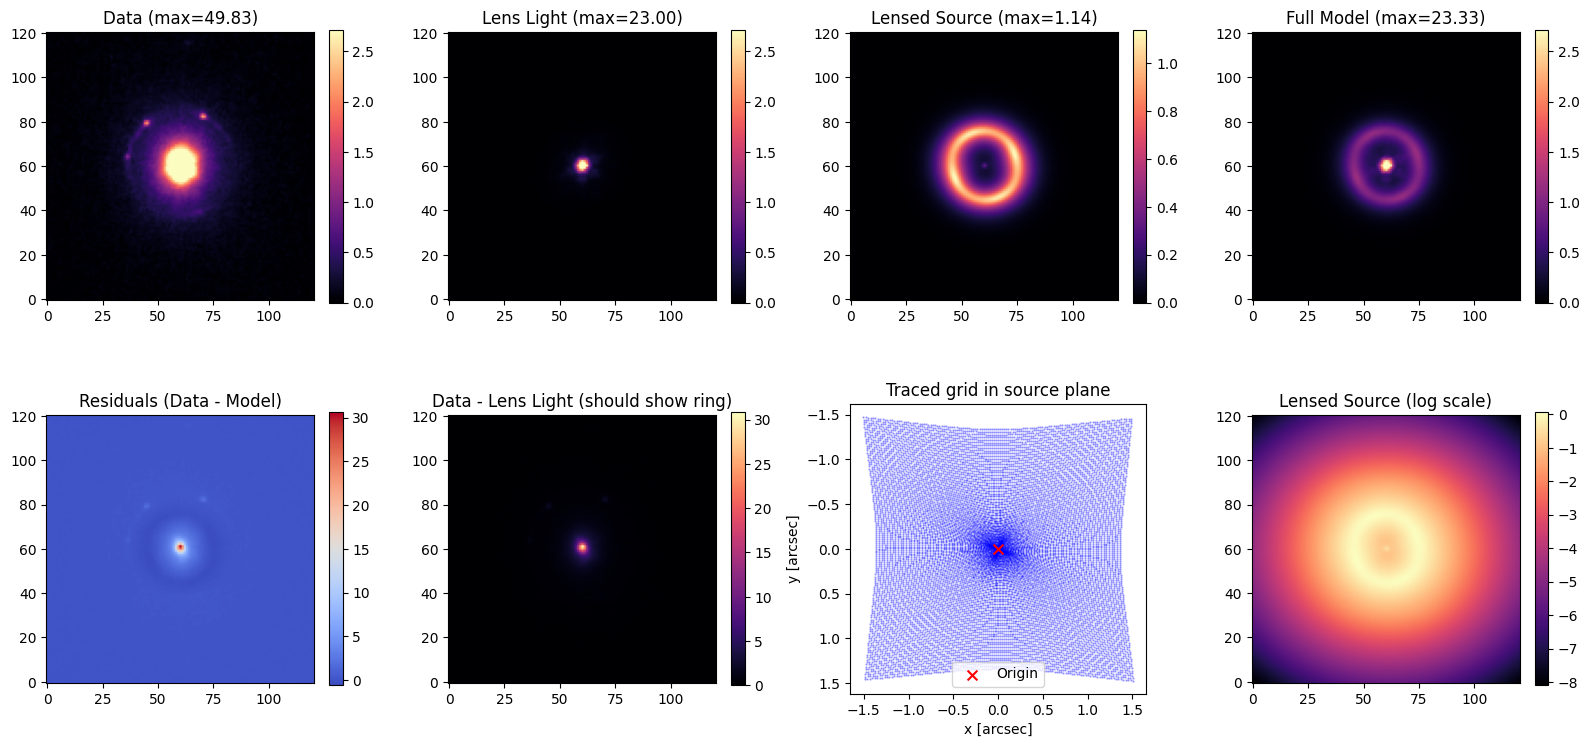


=== Einstein Ring Check ===
Source centre: [0. 0.]
Einstein radius: 1.0 arcsec
Einstein radius in pixels: 33.3
Image size: (121, 121) at 0.03 arcsec/pixel


In [12]:
# Diagnostic: Visualize model components separately to debug Einstein ring visibility

from jax_lens.lens.tracer import traced_grid_list, compute_plane_image

# Get traced grid to source plane
traced_grids = traced_grid_list(grid_flat, config, params_cache)
source_plane_grid = traced_grids[-1]  # Last plane is source

# Compute lens light only (evaluated at image plane)
lens_light_only = compute_plane_image(
    grid_flat, 
    ('sersic',), 
    [params_cache["planes"][0]["light"][0]]
).reshape(image_shape)

# Compute source light only (evaluated at traced/source plane positions)
source_light_only = compute_plane_image(
    source_plane_grid,
    ('sersic',),
    [params_cache["planes"][1]["light"][0]]
).reshape(image_shape)

# Compute full model
full_model = tracer_image(grid_flat, config, params_cache).reshape(image_shape)

# Convolve with PSF for fair comparison
if ds.psf is not None:
    lens_light_conv = convolve_image(lens_light_only, ds.psf, padding="edge")
    source_light_conv = convolve_image(source_light_only, ds.psf, padding="edge")
    full_model_conv = convolve_image(full_model, ds.psf, padding="edge")
else:
    lens_light_conv = lens_light_only
    source_light_conv = source_light_only
    full_model_conv = full_model

# Print flux statistics
print("=== Flux Statistics ===")
print(f"Data: max={float(data.max()):.4f}, sum={float(data.sum()):.4f}")
print(f"Lens light (conv): max={float(lens_light_conv.max()):.4f}, sum={float(lens_light_conv.sum()):.4f}")
print(f"Source light (conv): max={float(source_light_conv.max()):.4f}, sum={float(source_light_conv.sum()):.4f}")
print(f"Full model (conv): max={float(full_model_conv.max()):.4f}, sum={float(full_model_conv.sum()):.4f}")

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Top row: individual components
vmax_data = float(jnp.percentile(data, 99))
im0 = axes[0, 0].imshow(data, origin="lower", cmap="magma", vmin=0, vmax=vmax_data)
axes[0, 0].set_title(f"Data (max={float(data.max()):.2f})")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(lens_light_conv, origin="lower", cmap="magma", vmin=0, vmax=vmax_data)
axes[0, 1].set_title(f"Lens Light (max={float(lens_light_conv.max()):.2f})")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

im2 = axes[0, 2].imshow(source_light_conv, origin="lower", cmap="magma", vmin=0)
axes[0, 2].set_title(f"Lensed Source (max={float(source_light_conv.max()):.2f})")
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

im3 = axes[0, 3].imshow(full_model_conv, origin="lower", cmap="magma", vmin=0, vmax=vmax_data)
axes[0, 3].set_title(f"Full Model (max={float(full_model_conv.max()):.2f})")
plt.colorbar(im3, ax=axes[0, 3], fraction=0.046)

# Bottom row: residuals and source plane
im4 = axes[1, 0].imshow(data - full_model_conv, origin="lower", cmap="coolwarm")
axes[1, 0].set_title("Residuals (Data - Model)")
plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

im5 = axes[1, 1].imshow(data - lens_light_conv, origin="lower", cmap="magma", vmin=0)
axes[1, 1].set_title("Data - Lens Light (should show ring)")
plt.colorbar(im5, ax=axes[1, 1], fraction=0.046)

# Source plane coverage
axes[1, 2].scatter(source_plane_grid[:, 1], source_plane_grid[:, 0], s=0.5, alpha=0.3, c='blue')
axes[1, 2].scatter(0, 0, s=50, c='red', marker='x', label='Origin')
axes[1, 2].set_title("Traced grid in source plane")
axes[1, 2].set_xlabel("x [arcsec]")
axes[1, 2].set_ylabel("y [arcsec]")
axes[1, 2].set_aspect('equal')
axes[1, 2].invert_yaxis()
axes[1, 2].legend()

# Log-scale comparison
im7 = axes[1, 3].imshow(jnp.log10(jnp.maximum(source_light_conv, 1e-10)), origin="lower", cmap="magma")
axes[1, 3].set_title("Lensed Source (log scale)")
plt.colorbar(im7, ax=axes[1, 3], fraction=0.046)

plt.tight_layout()
plt.show()

# Check if Einstein ring structure is present
print("\n=== Einstein Ring Check ===")
print(f"Source centre: {params_cache['planes'][1]['light'][0]['centre']}")
print(f"Einstein radius: {params_cache['planes'][0]['mass'][0]['einstein_radius']} arcsec")
print(f"Einstein radius in pixels: {params_cache['planes'][0]['mass'][0]['einstein_radius'] / ds.pixel_scale:.1f}")
print(f"Image size: {image_shape} at {ds.pixel_scale} arcsec/pixel")

=== Grid Diagnostics ===
grid shape: (121, 121, 2)
grid_flat shape: (14641, 2)
grid min (y, x): (-1.8000, -1.8000)
grid max (y, x): (1.8000, 1.8000)
grid center value: [0. 0.]
pixel_scale: 0.03

=== Lens Light Parameters ===
  centre: [0. 0.]
  intensity: 0.1
  effective_radius: 0.25
  sersic_index: 4.0
  axis_ratio: 0.7
  angle: 0.6

=== Elliptical Radius ===
r_ell min: 0.000001
r_ell max: 3.604901
r_ell at center pixel: 0.000001

=== Sersic Profile Values ===
Sersic min: 0.000069
Sersic max: 151.970158
Sersic sum: 250.40
Sersic has NaN: False
Sersic has Inf: False


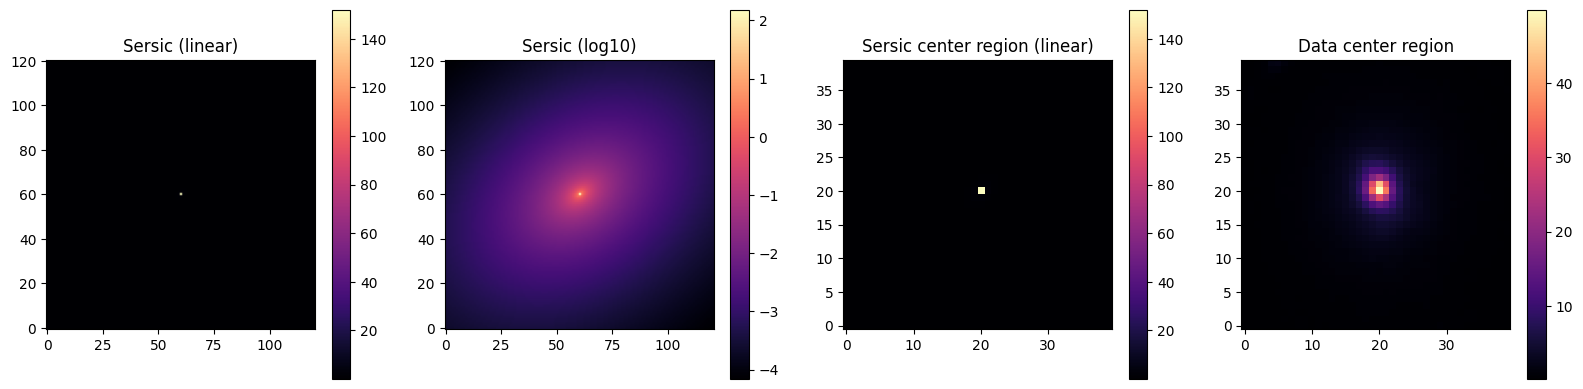


=== Grid Ordering Check ===
grid[0, 0] (top-left): [-1.8 -1.8]
grid[0, -1] (top-right): [-1.8  1.8]
grid[-1, 0] (bottom-left): [ 1.8 -1.8]
grid[-1, -1] (bottom-right): [1.8 1.8]

=== Comparing grid sources ===
ds.grid center: [-4.4408921e-16 -4.4408921e-16]
create_grid center: [0. 0.]
Grids match: True


In [13]:
# Debug: Check grid and Sersic profile directly

from jax_lens.profiles.light import sersic, _elliptical_radius

print("=== Grid Diagnostics ===")
print(f"grid shape: {grid.shape}")
print(f"grid_flat shape: {grid_flat.shape}")
print(f"grid min (y, x): ({float(grid_flat[:, 0].min()):.4f}, {float(grid_flat[:, 1].min()):.4f})")
print(f"grid max (y, x): ({float(grid_flat[:, 0].max()):.4f}, {float(grid_flat[:, 1].max()):.4f})")
print(f"grid center value: {grid[crop_size//2, crop_size//2]}")
print(f"pixel_scale: {ds.pixel_scale}")

# Check the lens light parameters
lens_params = params_cache["planes"][0]["light"][0]
print("\n=== Lens Light Parameters ===")
for k, v in lens_params.items():
    print(f"  {k}: {v}")

# Compute elliptical radius directly
r_ell = _elliptical_radius(
    grid_flat,
    lens_params["centre"],
    lens_params["axis_ratio"],
    lens_params["angle"]
)
print(f"\n=== Elliptical Radius ===")
print(f"r_ell min: {float(r_ell.min()):.6f}")
print(f"r_ell max: {float(r_ell.max()):.6f}")
print(f"r_ell at center pixel: {float(r_ell[len(r_ell)//2]):.6f}")

# Compute Sersic profile directly
sersic_values = sersic(
    grid_flat,
    centre=lens_params["centre"],
    intensity=lens_params["intensity"],
    effective_radius=lens_params["effective_radius"],
    sersic_index=lens_params["sersic_index"],
    axis_ratio=lens_params["axis_ratio"],
    angle=lens_params["angle"],
)

print(f"\n=== Sersic Profile Values ===")
print(f"Sersic min: {float(sersic_values.min()):.6f}")
print(f"Sersic max: {float(sersic_values.max()):.6f}")
print(f"Sersic sum: {float(sersic_values.sum()):.2f}")
print(f"Sersic has NaN: {bool(jnp.any(jnp.isnan(sersic_values)))}")
print(f"Sersic has Inf: {bool(jnp.any(jnp.isinf(sersic_values)))}")

# Visualize the Sersic profile with different scales
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sersic_2d = sersic_values.reshape(image_shape)

im0 = axes[0].imshow(sersic_2d, origin="lower", cmap="magma")
axes[0].set_title("Sersic (linear)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(jnp.log10(jnp.maximum(sersic_2d, 1e-10)), origin="lower", cmap="magma")
axes[1].set_title("Sersic (log10)")
plt.colorbar(im1, ax=axes[1])

# Show just the center region
center = crop_size // 2
hw = 20  # half-width
im2 = axes[2].imshow(sersic_2d[center-hw:center+hw, center-hw:center+hw], origin="lower", cmap="magma")
axes[2].set_title("Sersic center region (linear)")
plt.colorbar(im2, ax=axes[2])

# Compare with data center
im3 = axes[3].imshow(data[center-hw:center+hw, center-hw:center+hw], origin="lower", cmap="magma")
axes[3].set_title("Data center region")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

# Check grid ordering - is it row-major or column-major?
print("\n=== Grid Ordering Check ===")
print(f"grid[0, 0] (top-left): {grid[0, 0]}")
print(f"grid[0, -1] (top-right): {grid[0, -1]}")
print(f"grid[-1, 0] (bottom-left): {grid[-1, 0]}")
print(f"grid[-1, -1] (bottom-right): {grid[-1, -1]}")

# Check if using ds.grid vs create_grid gives different results
print("\n=== Comparing grid sources ===")
if ds.grid is not None:
    # Handle 3D grid (ny, nx, 2) - crop the first two dimensions
    def crop_grid_3d(arr, size):
        ny, nx = arr.shape[:2]
        y0 = (ny - size) // 2
        x0 = (nx - size) // 2
        return arr[y0:y0+size, x0:x0+size, :]
    
    ds_grid_cropped = crop_grid_3d(ds.grid, crop_size) if crop_size else ds.grid
    print(f"ds.grid center: {ds_grid_cropped[crop_size//2, crop_size//2]}")
    print(f"create_grid center: {grid[crop_size//2, crop_size//2]}")
    print(f"Grids match: {bool(jnp.allclose(ds_grid_cropped, grid))}")

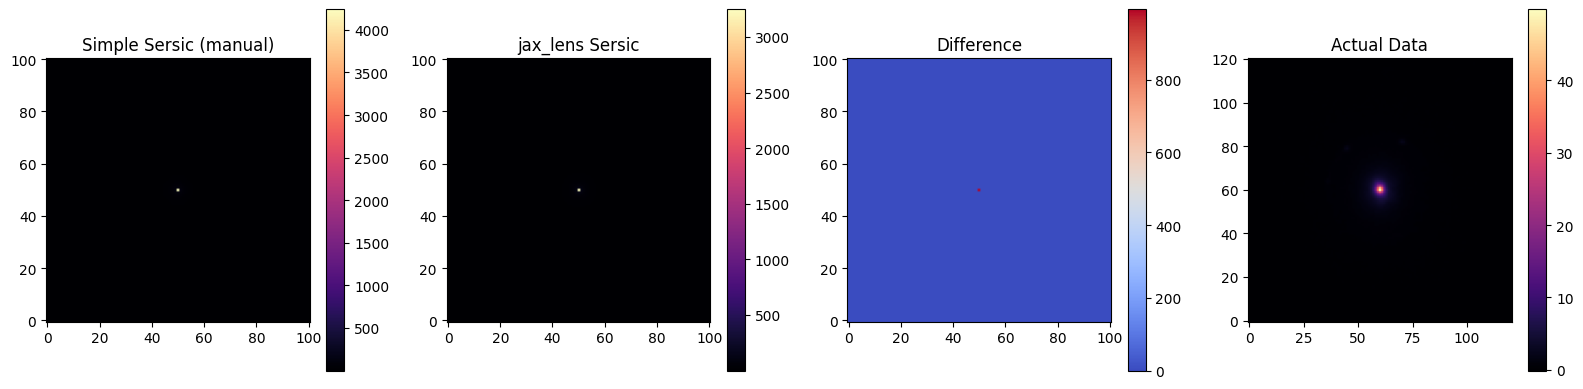

Simple Sersic max: 4245.31
jax_lens Sersic max: 3251.39
Max difference: 993.920687

=== Data Center Analysis ===
Data value at center [60, 60]: 49.8293
Data max value: 49.8293
Data max location (y, x): (60, 60)
Offset from center: (0, 0) pixels
Offset in arcsec: (0.000, 0.000)


In [14]:
# Sanity check: Create a simple Sersic from scratch (no jax_lens machinery)
# This verifies if the issue is in the profile code or the pipeline

import jax.numpy as jnp

# Create a simple test grid
test_n = 101
test_scale = 0.03
test_coords = jnp.linspace(-(test_n-1)/2 * test_scale, (test_n-1)/2 * test_scale, test_n)
test_yy, test_xx = jnp.meshgrid(test_coords, test_coords, indexing="ij")

# Simple circular Sersic (n=4) centered at origin
r = jnp.sqrt(test_yy**2 + test_xx**2)
r = jnp.maximum(r, 1e-12)
n = 4.0
Re = 0.6
bn = 2.0 * n - 1.0/3.0 + 4.0/(405.0*n)  # Ciotti & Bertin approximation
intensity = 2.0

simple_sersic = intensity * jnp.exp(-bn * ((r / Re)**(1.0/n) - 1.0))

# Now compute using jax_lens
from jax_lens.profiles.light import sersic

test_grid_flat = jnp.stack([test_yy.ravel(), test_xx.ravel()], axis=-1)
jaxlens_sersic = sersic(
    test_grid_flat,
    centre=jnp.array([0.0, 0.0]),
    intensity=2.0,
    effective_radius=0.6,
    sersic_index=4.0,
    axis_ratio=1.0,
    angle=0.0,
).reshape(test_n, test_n)

# Compare
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(simple_sersic, origin="lower", cmap="magma")
axes[0].set_title("Simple Sersic (manual)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(jaxlens_sersic, origin="lower", cmap="magma")
axes[1].set_title("jax_lens Sersic")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(simple_sersic - jaxlens_sersic, origin="lower", cmap="coolwarm")
axes[2].set_title("Difference")
plt.colorbar(im2, ax=axes[2])

# Check the actual data to see where the galaxy is
im3 = axes[3].imshow(data, origin="lower", cmap="magma")
axes[3].set_title("Actual Data")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

print(f"Simple Sersic max: {float(simple_sersic.max()):.2f}")
print(f"jax_lens Sersic max: {float(jaxlens_sersic.max()):.2f}")
print(f"Max difference: {float(jnp.abs(simple_sersic - jaxlens_sersic).max()):.6f}")

# Check if data center is actually where the lens galaxy is
center_idx = crop_size // 2
print(f"\n=== Data Center Analysis ===")
print(f"Data value at center [{center_idx}, {center_idx}]: {float(data[center_idx, center_idx]):.4f}")
print(f"Data max value: {float(data.max()):.4f}")
max_idx = jnp.unravel_index(jnp.argmax(data), data.shape)
print(f"Data max location (y, x): ({int(max_idx[0])}, {int(max_idx[1])})")
print(f"Offset from center: ({int(max_idx[0]) - center_idx}, {int(max_idx[1]) - center_idx}) pixels")
print(f"Offset in arcsec: ({(int(max_idx[0]) - center_idx) * ds.pixel_scale:.3f}, {(int(max_idx[1]) - center_idx) * ds.pixel_scale:.3f})")

In [15]:
assert False

AssertionError: 

In [ ]:
# Sampling with optional cache refresh

def sample_stage(rng_key, theta_start, cache):
    def log_posterior(theta: jnp.ndarray) -> jnp.ndarray:
        params = unpack_theta(theta)
        return log_like_eval(params) + log_prior(theta)

    log_posterior_jit = jax.jit(log_posterior)

    t0 = time.time()
    _ = jax.block_until_ready(log_posterior_jit(theta_start))
    print(f"Compilation done in {time.time() - t0:.1f}s")

    rng_key, rng_adapt, rng_sample = jr.split(rng_key, 3)
    adapt = window_adaptation(
        blackjax.nuts,
        log_posterior_jit,
        initial_step_size=0.02,
        target_acceptance_rate=0.8,
        is_mass_matrix_diagonal=True,
    )
    adapt_results, adapt_info = adapt.run(rng_adapt, theta_start, num_steps=num_adapt)

    nuts = blackjax.nuts.differentiable(
        log_posterior_jit,
        **adapt_results.parameters,
    )

    @jax.jit
    def one_step(state, key):
        new_state, info = nuts.step(key, state)
        return new_state, (new_state, info)

    keys = jr.split(rng_sample, num_samples)
    state, (states, infos) = jax.lax.scan(one_step, adapt_results.state, keys)
    samples = states.position

    return samples, state, rng_key

def maybe_refresh_cache(cache, theta_ref, theta_new):
    if source_mode != "pixelization":
        return cache, theta_ref

    drift = theta_drift(theta_ref, theta_new)
    if drift < refresh_threshold:
        return cache, theta_ref

    params_cache = unpack_theta(theta_new)
    cache = build_pixelization_cache_from_tracer(
        grid=grid_flat,
        config=config,
        params=params_cache,
        seeds=seeds,
    )
    return cache, theta_new

rng = jr.PRNGKey(10)
theta_current = theta_init
cache_current = cache
theta_ref = theta_init

all_samples = []
for stage in range(num_stages):
    samples, state, rng = sample_stage(rng, theta_current, cache_current)
    all_samples.append(samples)

    mean_theta = jnp.mean(samples[burn_in:], axis=0)
    cache_current, theta_ref = maybe_refresh_cache(cache_current, theta_ref, mean_theta)

    theta_current = samples[-1]

samples = jnp.concatenate(all_samples, axis=0)

if 'infos' in locals():
    acc_rate = jnp.mean(infos.acceptance_probability)
    print("Mean acceptance probability:", float(acc_rate))


In [ ]:
# Posterior summary and reconstruction

posterior_tree = jax.vmap(unpack_theta)(samples[burn_in:])
mean_params = jax.tree.map(lambda x: jnp.mean(x, axis=0), posterior_tree)

print("Einstein radius (mean):", float(mean_params["planes"][0]["mass"][0]["einstein_radius"]))
print("Axis ratio (mean):", float(mean_params["planes"][0]["mass"][0]["axis_ratio"]))
print("Centre (mean y, x):", np.round(np.array(mean_params["planes"][0]["mass"][0]["centre"]), 3))

print("Lens light Re (mean):", float(mean_params["planes"][0]["light"][0]["effective_radius"]))
print("Lens light n (mean):", float(mean_params["planes"][0]["light"][0]["sersic_index"]))

if source_mode == "pixelization":
    traced_mean = traced_grid_list(grid_flat, config, mean_params)[-1]
    source_model, source_values = pixelized_source_reconstruction(
        points=traced_mean,
        seeds=jnp.asarray(seeds),
        cache=cache_current,
        data=data_flat,
        noise_map=noise_flat,
        regularization_weight=pix_cfg.regularization_weight,
        solver=pix_cfg.solver,
        psf=ds.psf,
        image_shape=image_shape,
        mask=mask,
    )

    model_recon = source_model.reshape(image_shape)
else:
    model_recon = tracer_image(grid_flat, config, mean_params).reshape(image_shape)
    if ds.psf is not None:
        model_recon = convolve_image(model_recon, ds.psf, padding="edge")

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

im0 = axes[0].imshow(data, origin="lower", cmap="magma", vmin=1e-2, vmax=1)
axes[0].set_title("Data")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(model_recon, origin="lower", cmap="magma", vmin=1e-2, vmax=1)
axes[1].set_title("Model Reconstruction")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(data - np.array(model_recon), origin="lower", cmap="coolwarm")
axes[2].set_title("Residuals")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

if mask is not None:
    im3 = axes[3].imshow(mask, origin="lower", cmap="gray")
    axes[3].set_title("Mask")

plt.tight_layout()
plt.show()

if source_mode == "pixelization":
    plt.figure(figsize=(5, 4))
    plt.scatter(seeds[:, 1], seeds[:, 0], c=np.array(source_values), s=12, cmap="magma")
    plt.gca().invert_yaxis()
    plt.title("Recovered Source Values on Voronoi Seeds")
    plt.colorbar()
    plt.show()
